In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
# https://www.kaggle.com/datasets/tamber/steam-video-games
dataset = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/Recommendation_systems/steam-200k.csv',
    header=None,
    names=['user-id', 'game-title', 'behavior-name', 'value', 'timestamp'],
)
dataset

,user-id,game-title,behavior-name,value,timestamp
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0
...,...,...,...,...,...
199995,128470551,Titan Souls,play,1.5,0
199996,128470551,Grand Theft Auto Vice City,purchase,1.0,0
199997,128470551,Grand Theft Auto Vice City,play,1.5,0
199998,128470551,RUSH,purchase,1.0,0


Количество записей о времени игры: 70489


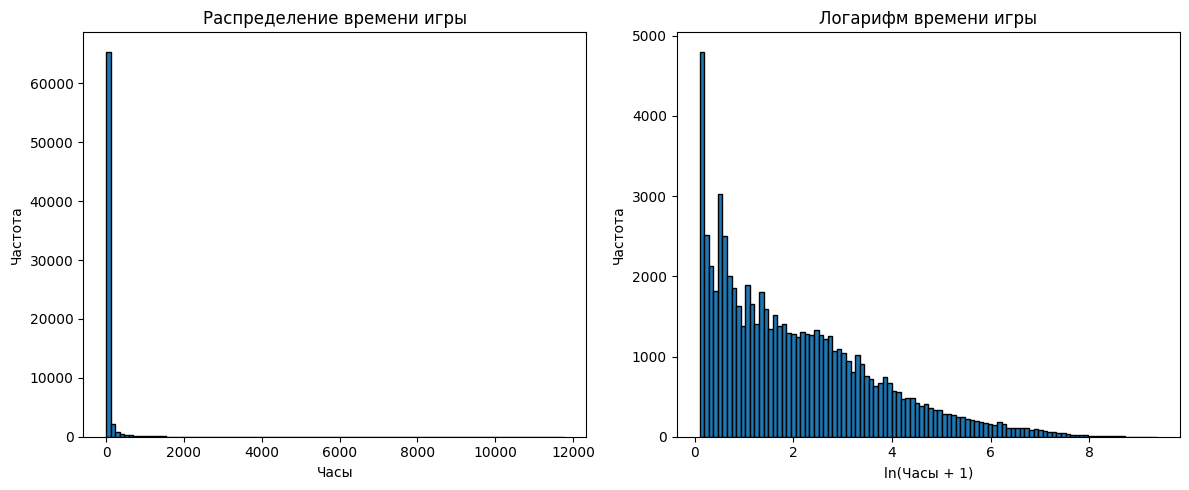

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Этап 2: Анализ и очистка данных
# Оставляем только взаимодействия 'play' с положительным временем
play_data = dataset[(dataset['behavior-name'] == 'play') & (dataset['value'] > 0)].copy()
print(f"Количество записей о времени игры: {len(play_data)}")

# Анализ распределения времени игры
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(play_data['value'], bins=100, edgecolor='black')
plt.title('Распределение времени игры')
plt.xlabel('Часы')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(play_data['value']), bins=100, edgecolor='black')
plt.title('Логарифм времени игры')
plt.xlabel('ln(Часы + 1)')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

# Логарифмирование времени игры для нормализации
play_data['log_value'] = np.log1p(play_data['value'])

Статистика времени игры:
Общее количество взаимодействий: 70489
Медиана времени игры: 4.50 часов
Среднее время игры: 48.88 часов
Максимальное время игры: 11754.00 часов
Минимальное время игры: 0.10 часов

Статистика по играм:
Медиана количества игроков на игру: 4.0
Максимальное количество игроков: 4841
Минимальное количество игроков: 1


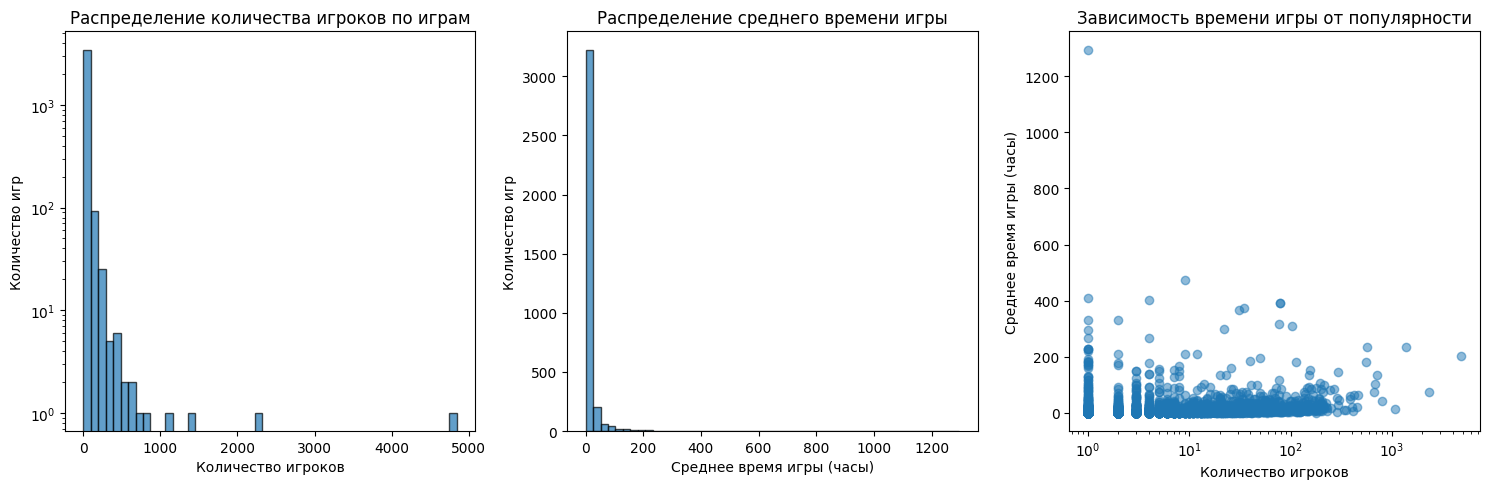

In [36]:
# Этап 3 (переработанный): Улучшенная подготовка данных
def analyze_rating_distribution(play_data):
    """Анализ распределения оценок (времени игры)"""
    print("Статистика времени игры:")
    print(f"Общее количество взаимодействий: {len(play_data)}")
    print(f"Медиана времени игры: {play_data['value'].median():.2f} часов")
    print(f"Среднее время игры: {play_data['value'].mean():.2f} часов")
    print(f"Максимальное время игры: {play_data['value'].max():.2f} часов")
    print(f"Минимальное время игры: {play_data['value'].min():.2f} часов")

    # Анализ по играм
    game_stats = play_data.groupby('game-title')['value'].agg(['count', 'mean', 'median', 'std']).reset_index()
    game_stats = game_stats.rename(columns={'count': 'num_players', 'mean': 'avg_hours', 'median': 'median_hours', 'std': 'std_hours'})

    print(f"\nСтатистика по играм:")
    print(f"Медиана количества игроков на игру: {game_stats['num_players'].median()}")
    print(f"Максимальное количество игроков: {game_stats['num_players'].max()}")
    print(f"Минимальное количество игроков: {game_stats['num_players'].min()}")

    return game_stats

game_stats = analyze_rating_distribution(play_data)

# Визуализация распределения популярности игр
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(game_stats['num_players'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение количества игроков по играм')
plt.xlabel('Количество игроков')
plt.ylabel('Количество игр')
plt.yscale('log')

plt.subplot(1, 3, 2)
plt.hist(game_stats['avg_hours'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение среднего времени игры')
plt.xlabel('Среднее время игры (часы)')
plt.ylabel('Количество игр')

plt.subplot(1, 3, 3)
plt.scatter(game_stats['num_players'], game_stats['avg_hours'], alpha=0.5)
plt.title('Зависимость времени игры от популярности')
plt.xlabel('Количество игроков')
plt.ylabel('Среднее время игры (часы)')
plt.xscale('log')

plt.tight_layout()
plt.show()

In [37]:
# Улучшенная нормализация оценок
def improved_normalization(play_data, game_stats):
    """Улучшенная нормализация с учетом персональных предпочтений и популярности"""

    # 1. Нормализация по пользователям (учет игровых привычек)
    print("Нормализация по пользователям...")
    user_stats = play_data.groupby('user-id')['value'].agg(['mean', 'std']).reset_index()
    user_stats = user_stats.rename(columns={'mean': 'user_mean', 'std': 'user_std'})

    # Объединяем с исходными данными
    play_data_normalized = play_data.merge(user_stats, on='user-id', how='left')

    # Z-score нормализация по пользователю
    play_data_normalized['user_z_score'] = (play_data_normalized['value'] - play_data_normalized['user_mean']) / play_data_normalized['user_std']

    # Замена NaN (когда std = 0) на 0
    play_data_normalized['user_z_score'] = play_data_normalized['user_z_score'].fillna(0)

    # 2. Нормализация по играм (учет сложности/продолжительности игры)
    print("Нормализация по играм...")
    play_data_normalized = play_data_normalized.merge(
        game_stats[['game-title', 'avg_hours', 'num_players']],
        on='game-title',
        how='left'
    )

    # Нормализация относительно среднего по игре
    play_data_normalized['game_relative'] = play_data_normalized['value'] / play_data_normalized['avg_hours']

    # 3. Комбинированная нормализация
    # Вес, который балансирует между персональными предпочтениями и абсолютным временем
    play_data_normalized['combined_rating'] = (
        0.6 * play_data_normalized['user_z_score'] +  # Персональное предпочтение
        0.4 * np.log1p(play_data_normalized['value']) / 5.0  # Абсолютное время (нормализованное)
    )

    # 4. Учет популярности с понижающим весом
    # Игры с большим количеством игроков получают меньший вес в персонализации
    popularity_weight = 1 / (1 + np.log1p(play_data_normalized['num_players']) / 10.0)
    play_data_normalized['final_rating'] = play_data_normalized['combined_rating'] * popularity_weight

    # Масштабирование к диапазону [0, 1]
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    play_data_normalized['final_rating'] = scaler.fit_transform(play_data_normalized[['final_rating']])

    return play_data_normalized

play_data_orig = play_data
play_data = improved_normalization(play_data, game_stats)

print("\nСтатистика нормализованных оценок:")
print(f"Min: {play_data['final_rating'].min():.3f}")
print(f"Max: {play_data['final_rating'].max():.3f}")
print(f"Mean: {play_data['final_rating'].mean():.3f}")
print(f"Std: {play_data['final_rating'].std():.3f}")

Нормализация по пользователям...
Нормализация по играм...

Статистика нормализованных оценок:
Min: 0.000
Max: 1.000
Mean: 0.142
Std: 0.054


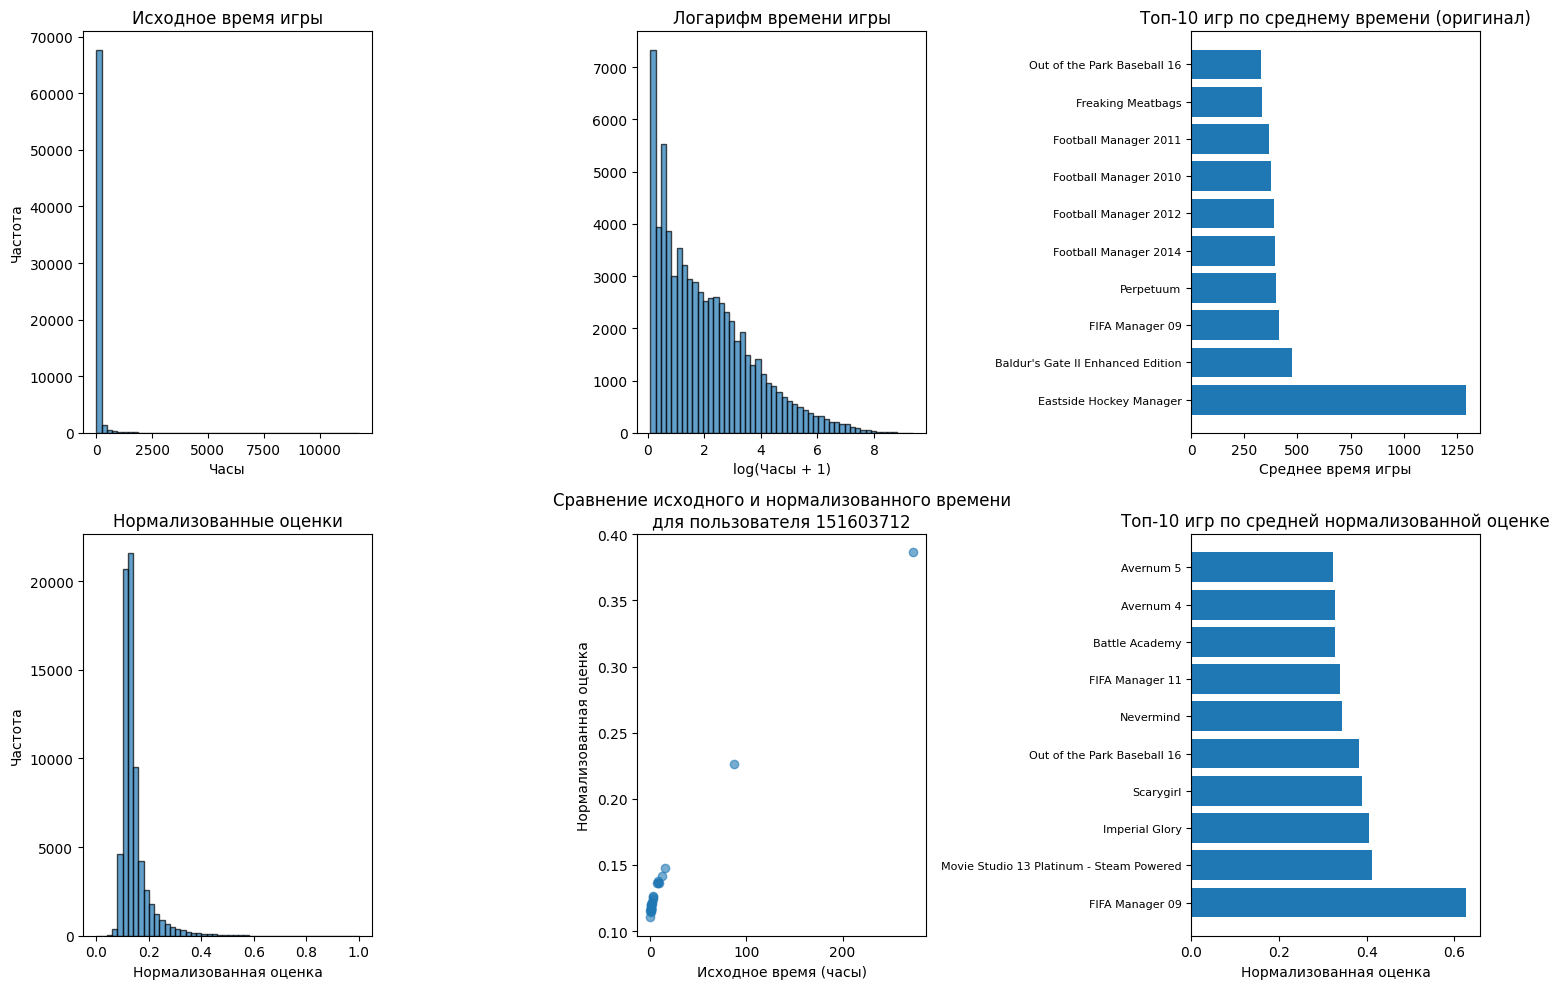

In [38]:
# Визуализация эффекта нормализации
plt.figure(figsize=(15, 10))

# До нормализации
plt.subplot(2, 3, 1)
plt.hist(play_data_orig['value'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Исходное время игры')
plt.xlabel('Часы')
plt.ylabel('Частота')

plt.subplot(2, 3, 2)
plt.hist(np.log1p(play_data_orig['value']), bins=50, edgecolor='black', alpha=0.7)
plt.title('Логарифм времени игры')
plt.xlabel('log(Часы + 1)')

plt.subplot(2, 3, 3)
top_games_original = play_data_orig.groupby('game-title')['value'].mean().sort_values(ascending=False).head(10)
plt.barh(range(len(top_games_original)), top_games_original.values)
plt.yticks(range(len(top_games_original)), top_games_original.index, fontsize=8)
plt.title('Топ-10 игр по среднему времени (оригинал)')
plt.xlabel('Среднее время игры')

# После нормализации
plt.subplot(2, 3, 4)
plt.hist(play_data['final_rating'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Нормализованные оценки')
plt.xlabel('Нормализованная оценка')
plt.ylabel('Частота')

plt.subplot(2, 3, 5)
user_sample = play_data['user-id'].iloc[0]
user_ratings = play_data[play_data['user-id'] == user_sample]
plt.scatter(user_ratings['value'], user_ratings['final_rating'], alpha=0.6)
plt.title(f'Сравнение исходного и нормализованного времени\nдля пользователя {user_sample}')
plt.xlabel('Исходное время (часы)')
plt.ylabel('Нормализованная оценка')

plt.subplot(2, 3, 6)
top_games_normalized = play_data.groupby('game-title')['final_rating'].mean().sort_values(ascending=False).head(10)
plt.barh(range(len(top_games_normalized)), top_games_normalized.values)
plt.yticks(range(len(top_games_normalized)), top_games_normalized.index, fontsize=8)
plt.title('Топ-10 игр по средней нормализованной оценке')
plt.xlabel('Нормализованная оценка')

plt.tight_layout()
plt.show()

In [43]:
# Обновленная матрица взаимодействий с нормализованными оценками
user_ids = play_data['user-id'].unique()
game_titles = play_data['game-title'].unique()

user_to_idx = {user: idx for idx, user in enumerate(user_ids)}
game_to_idx = {game: idx for idx, game in enumerate(game_titles)}

print(f"Количество уникальных пользователей: {len(user_ids)}")
print(f"Количество уникальных игр: {len(game_titles)}")

# Создаем разреженную матрицу взаимодействий
def create_interaction_matrix(data, user_to_idx, game_to_idx):
    n_users = len(user_to_idx)
    n_games = len(game_to_idx)
    interactions = np.zeros((n_users, n_games))

    for _, row in data.iterrows():
        user_idx = user_to_idx[row['user-id']]
        game_idx = game_to_idx[row['game-title']]
        interactions[user_idx, game_idx] = row['final_rating']

    return interactions

interaction_matrix = create_interaction_matrix(play_data, user_to_idx, game_to_idx)
print(f"Размер матрицы взаимодействий: {interaction_matrix.shape}")
print(f"Заполненность матрицы: {np.count_nonzero(interaction_matrix) / (interaction_matrix.shape[0] * interaction_matrix.shape[1]) * 100:.4f}%")

Количество уникальных пользователей: 11350
Количество уникальных игр: 3600
Размер матрицы взаимодействий: (11350, 3600)
Заполненность матрицы: 0.1725%


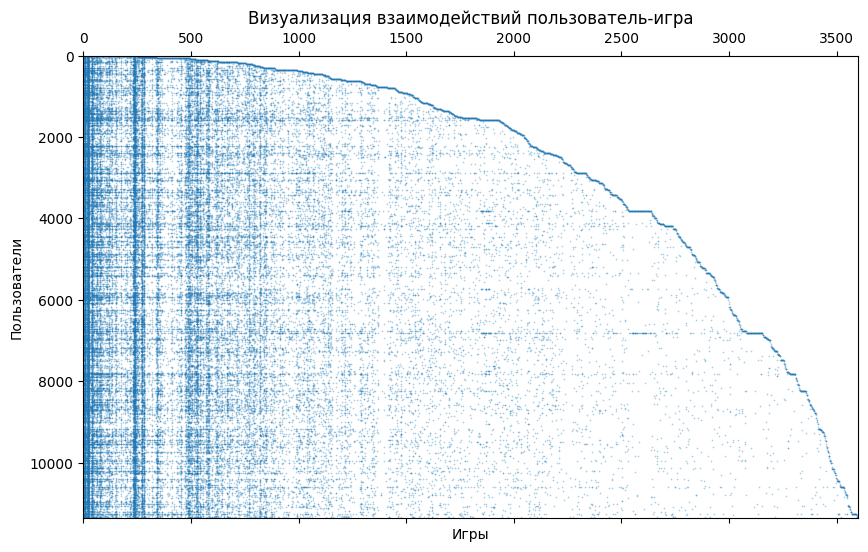

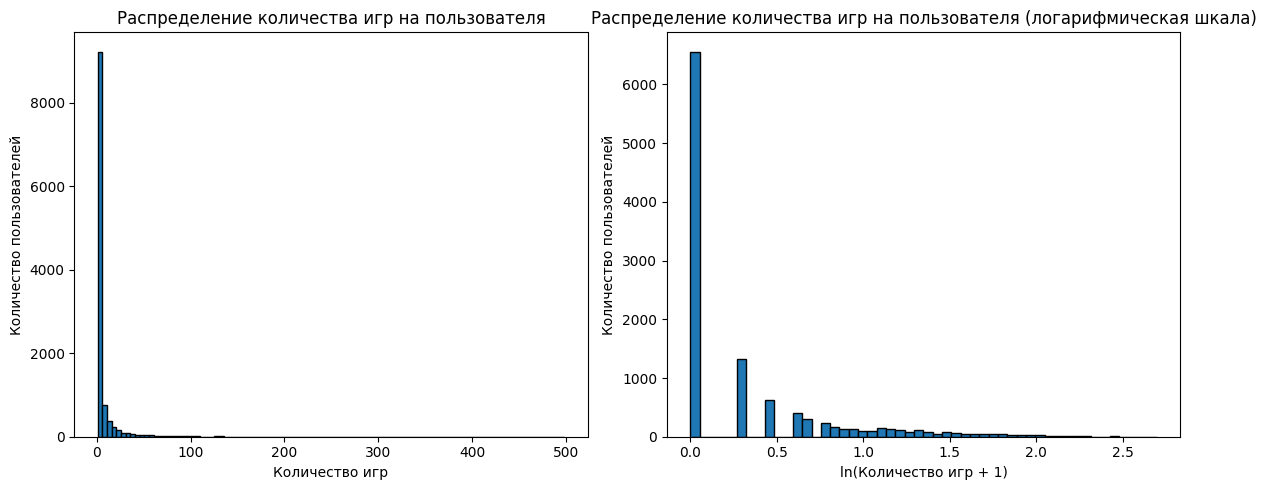

In [44]:
# Этап 4: Визуализация плотности данных
plt.figure(figsize=(10, 6))
nonzero_mask = interaction_matrix > 0
plt.spy(nonzero_mask, markersize=0.1, aspect='auto')
plt.title('Визуализация взаимодействий пользователь-игра')
plt.xlabel('Игры')
plt.ylabel('Пользователи')
plt.show()

# Анализ количества игр на пользователя
games_per_user = np.sum(interaction_matrix > 0, axis=1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(games_per_user, bins=100, edgecolor='black')
plt.title('Распределение количества игр на пользователя')
plt.xlabel('Количество игр')
plt.ylabel('Количество пользователей')

plt.subplot(1, 2, 2)
plt.hist(np.log10(games_per_user), bins=50, edgecolor='black')
plt.title('Распределение количества игр на пользователя (логарифмическая шкала)')
plt.xlabel('ln(Количество игр + 1)')
plt.ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

In [52]:
# Исправленная реализация Funk SVD с лучшей численной стабильностью
class FunkSVDStable:
    def __init__(self, n_factors=50, learning_rate=0.001, regularization=0.02, n_epochs=20):
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.regularization = regularization
        self.n_epochs = n_epochs

    def fit(self, interactions):
        self.interactions = interactions
        n_users, n_items = interactions.shape

        # Инициализация с меньшими значениями для стабильности
        self.user_factors = np.random.normal(0, 0.1, (n_users, self.n_factors))
        self.item_factors = np.random.normal(0, 0.05, (n_items, self.n_factors))
        self.user_bias = np.zeros(n_users)
        self.item_bias = np.zeros(n_items)
        self.global_bias = np.mean(interactions[interactions > 0])

        # Обучение с помощью SGD с проверкой численной стабильности
        for epoch in range(self.n_epochs):
            total_error = 0
            count = 0

            # Случайный порядок обновления для лучшей сходимости
            user_indices = np.arange(n_users)
            np.random.shuffle(user_indices)

            for u in user_indices:
                item_indices = np.where(interactions[u] > 0)[0]
                np.random.shuffle(item_indices)

                for i in item_indices:
                    rating = interactions[u, i]

                    # Предсказание с bias terms
                    prediction = (self.global_bias +
                                 self.user_bias[u] +
                                 self.item_bias[i] +
                                 np.dot(self.user_factors[u], self.item_factors[i]))

                    error = rating - prediction
                    total_error += error ** 2
                    count += 1

                    # Обновление с clipping градиентов
                    user_bias_update = self.learning_rate * (error - self.regularization * self.user_bias[u])
                    item_bias_update = self.learning_rate * (error - self.regularization * self.item_bias[i])

                    user_factor_update = self.learning_rate * (
                        error * self.item_factors[i] - self.regularization * self.user_factors[u]
                    )
                    item_factor_update = self.learning_rate * (
                        error * self.user_factors[u] - self.regularization * self.item_factors[i]
                    )

                    # Применение обновлений
                    self.user_bias[u] += user_bias_update
                    self.item_bias[i] += item_bias_update
                    self.user_factors[u] += user_factor_update
                    self.item_factors[i] += item_factor_update

            if count > 0:
                rmse = np.sqrt(total_error / count)
                if epoch % 5 == 0:
                    print(f"Эпоха {epoch}, RMSE: {rmse:.4f}")

    def predict(self, u, i):
        return (self.global_bias +
                self.user_bias[u] +
                self.item_bias[i] +
                np.dot(self.user_factors[u], self.item_factors[i]))

    def calculate_rmse(self, test_matrix):
        non_zero_mask = test_matrix > 0
        predictions = np.zeros_like(test_matrix)

        for u in range(test_matrix.shape[0]):
            for i in range(test_matrix.shape[1]):
                if test_matrix[u, i] > 0:
                    predictions[u, i] = self.predict(u, i)

        mse = np.mean((test_matrix[non_zero_mask] - predictions[non_zero_mask]) ** 2)
        return np.sqrt(mse)

In [45]:
from sklearn.model_selection import KFold

# Этап 6: Кросс-валидация и оценка модели
def evaluate_funksvd_stable(interaction_matrix, n_factors=20, learning_rate=0.001,
                           regularization=0.02, n_epochs=15, n_folds=3):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    rmse_scores = []

    # Получаем индексы ненулевых элементов для разделения
    nonzero_indices = np.argwhere(interaction_matrix > 0)

    for fold, (train_idx, test_idx) in enumerate(kf.split(nonzero_indices)):
        print(f"Обработка фолда {fold + 1}/{n_folds}")

        # Создаем train и test матрицы
        train_matrix = np.zeros_like(interaction_matrix)
        test_matrix = np.zeros_like(interaction_matrix)

        # Заполняем train матрицу
        for idx in train_idx:
            u, i = nonzero_indices[idx]
            train_matrix[u, i] = interaction_matrix[u, i]

        # Заполняем test матрицу
        for idx in test_idx:
            u, i = nonzero_indices[idx]
            test_matrix[u, i] = interaction_matrix[u, i]

        # Обучение стабильной модели
        model = FunkSVDStable(
            n_factors=n_factors,
            learning_rate=learning_rate,
            regularization=regularization,
            n_epochs=n_epochs
        )
        model.fit(train_matrix)

        # Оценка на тестовых данных
        rmse = model.calculate_rmse(test_matrix)
        rmse_scores.append(rmse)
        print(f"Фолд {fold + 1}, RMSE: {rmse:.4f}")

    return np.mean(rmse_scores), np.std(rmse_scores)

# Тестируем исправленную версию
base_rmse, base_std = evaluate_funksvd_stable(interaction_matrix, n_factors=10, n_epochs=10)
print(f"Базовый RMSE: {base_rmse:.4f} ± {base_std:.4f}")

Обработка фолда 1/3
Эпоха 0, RMSE: 0.0535
Эпоха 5, RMSE: 0.0514
Фолд 1, RMSE: 0.0501
Обработка фолда 2/3
Эпоха 0, RMSE: 0.0529
Эпоха 5, RMSE: 0.0508
Фолд 2, RMSE: 0.0511
Обработка фолда 3/3
Эпоха 0, RMSE: 0.0526
Эпоха 5, RMSE: 0.0505
Фолд 3, RMSE: 0.0517
Базовый RMSE: 0.0510 ± 0.0007


Исследование влияния количества факторов:


  0%|          | 0/16 [00:00<?, ?it/s]

Обработка фолда 1/3
Эпоха 0, RMSE: 1.5734
Эпоха 5, RMSE: 1.4650
Фолд 1, RMSE: 1.4571
Обработка фолда 2/3
Эпоха 0, RMSE: 1.5803
Эпоха 5, RMSE: 1.4709
Фолд 2, RMSE: 1.4431
Обработка фолда 3/3
Эпоха 0, RMSE: 1.5769
Эпоха 5, RMSE: 1.4678


  6%|▋         | 1/16 [01:05<16:20, 65.40s/it]

Фолд 3, RMSE: 1.4485
Факторы: 10, RMSE: 1.4496
Обработка фолда 1/3
Эпоха 0, RMSE: 1.5735
Эпоха 5, RMSE: 1.4650
Фолд 1, RMSE: 1.4572
Обработка фолда 2/3
Эпоха 0, RMSE: 1.5804
Эпоха 5, RMSE: 1.4709
Фолд 2, RMSE: 1.4432
Обработка фолда 3/3
Эпоха 0, RMSE: 1.5776
Эпоха 5, RMSE: 1.4678


...

Фолд 3, RMSE: 1.4487
Факторы: 75, RMSE: 1.4497
Обработка фолда 1/3
Эпоха 0, RMSE: 1.5733
Эпоха 5, RMSE: 1.4649
Фолд 1, RMSE: 1.4571
Обработка фолда 2/3
Эпоха 0, RMSE: 1.5805
Эпоха 5, RMSE: 1.4708
Фолд 2, RMSE: 1.4432
Обработка фолда 3/3
Эпоха 0, RMSE: 1.5771
Эпоха 5, RMSE: 1.4677


 94%|█████████▍| 15/16 [15:49<01:03, 63.13s/it]

Фолд 3, RMSE: 1.4489
Факторы: 80, RMSE: 1.4497
Обработка фолда 1/3
Эпоха 0, RMSE: 1.5735
Эпоха 5, RMSE: 1.4649
Фолд 1, RMSE: 1.4572
Обработка фолда 2/3
Эпоха 0, RMSE: 1.5804
Эпоха 5, RMSE: 1.4708
Фолд 2, RMSE: 1.4431
Обработка фолда 3/3
Эпоха 0, RMSE: 1.5774
Эпоха 5, RMSE: 1.4677


100%|██████████| 16/16 [16:51<00:00, 63.23s/it]

Фолд 3, RMSE: 1.4486
Факторы: 90, RMSE: 1.4496


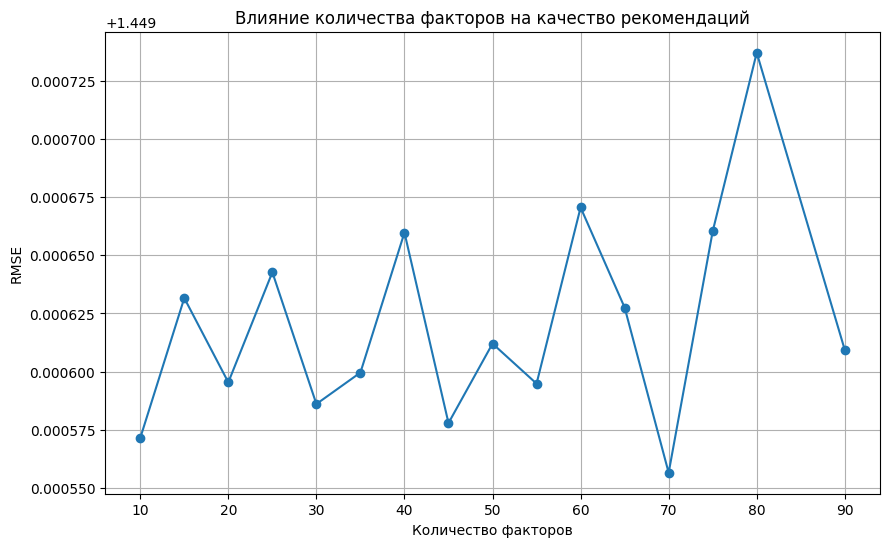

In [17]:
from tqdm import tqdm

# Этап 7: Исследование влияния гиперпараметров
# Исследуем влияние количества факторов
factors_range = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90]
rmse_results = []

print("Исследование влияния количества факторов:")
for n_factors in tqdm(factors_range):
    rmse, std = evaluate_funksvd_stable(
        interaction_matrix,
        n_factors=n_factors,
        n_epochs=10  # Уменьшаем для скорости
    )
    rmse_results.append(rmse)
    print(f"Факторы: {n_factors}, RMSE: {rmse:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(factors_range, rmse_results, marker='o')
plt.title('Влияние количества факторов на качество рекомендаций')
plt.xlabel('Количество факторов')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

Исследование влияния learning rate:


  0%|          | 0/9 [00:00<?, ?it/s]

Обработка фолда 1/3
Эпоха 0, RMSE: 1.5733
Эпоха 5, RMSE: 1.4650
Фолд 1, RMSE: 1.4571
Обработка фолда 2/3
Эпоха 0, RMSE: 1.5806
Эпоха 5, RMSE: 1.4707
Фолд 2, RMSE: 1.4431
Обработка фолда 3/3
Эпоха 0, RMSE: 1.5775
Эпоха 5, RMSE: 1.4677


 11%|█         | 1/9 [01:04<08:39, 64.99s/it]

Фолд 3, RMSE: 1.4485
Learning rate: 0.001, RMSE: 1.4496
Обработка фолда 1/3
Эпоха 0, RMSE: 1.5473
Эпоха 5, RMSE: 1.4087
Фолд 1, RMSE: 1.4193
Обработка фолда 2/3
Эпоха 0, RMSE: 1.5538
Эпоха 5, RMSE: 1.4148
Фолд 2, RMSE: 1.4051
Обработка фолда 3/3
Эпоха 0, RMSE: 1.5504
Эпоха 5, RMSE: 1.4114


...

Фолд 3, RMSE: 1.4315
Learning rate: 0.05, RMSE: 1.4311
Обработка фолда 1/3
Эпоха 0, RMSE: 1.4378
Эпоха 5, RMSE: 0.5568
Фолд 1, RMSE: 1.4470
Обработка фолда 2/3
Эпоха 0, RMSE: 1.4442
Эпоха 5, RMSE: 0.5535
Фолд 2, RMSE: 1.4378
Обработка фолда 3/3
Эпоха 0, RMSE: 1.4407
Эпоха 5, RMSE: 0.5534


 89%|████████▉ | 8/9 [08:20<01:02, 62.40s/it]

Фолд 3, RMSE: 1.4463
Learning rate: 0.075, RMSE: 1.4437
Обработка фолда 1/3
Эпоха 0, RMSE: 1.4430
Эпоха 5, RMSE: 0.3807
Фолд 1, RMSE: 1.4560
Обработка фолда 2/3
Эпоха 0, RMSE: 1.4511
Эпоха 5, RMSE: 0.3758
Фолд 2, RMSE: 1.4454
Обработка фолда 3/3
Эпоха 0, RMSE: 1.4440
Эпоха 5, RMSE: 0.3794


100%|██████████| 9/9 [09:21<00:00, 62.36s/it]

Фолд 3, RMSE: 1.4508
Learning rate: 0.1, RMSE: 1.4507


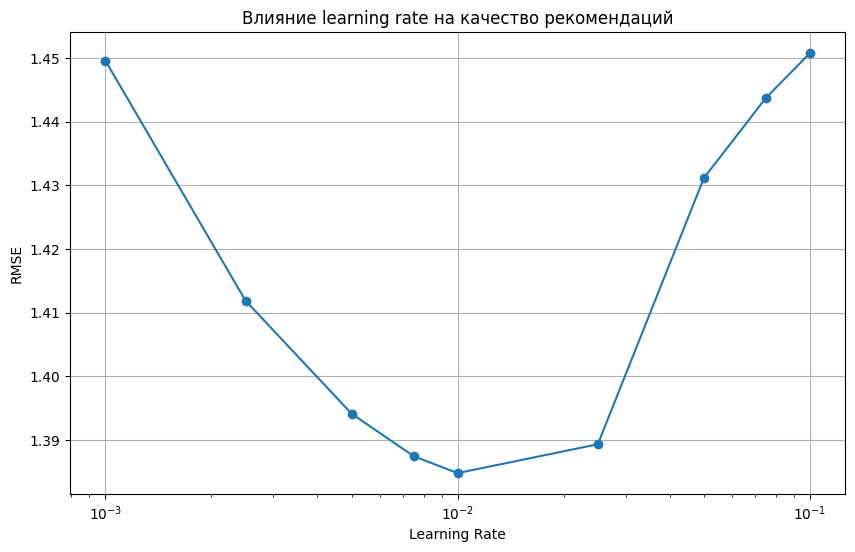

In [18]:
# Исследуем влияние learning rate
learning_rates = [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.025, 0.05, 0.075, 0.1]
rmse_lr_results = []

print("Исследование влияния learning rate:")
for lr in tqdm(learning_rates):
    rmse, std = evaluate_funksvd_stable(
        interaction_matrix,
        n_factors=70,
        learning_rate=lr,
        n_epochs=10
    )
    rmse_lr_results.append(rmse)
    print(f"Learning rate: {lr}, RMSE: {rmse:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(learning_rates, rmse_lr_results, marker='o')
plt.title('Влияние learning rate на качество рекомендаций')
plt.xlabel('Learning Rate')
plt.ylabel('RMSE')
plt.xscale('log')
plt.grid(True)
plt.show()

Исследование влияния регуляризации:


  0%|          | 0/11 [00:00<?, ?it/s]

Обработка фолда 1/3
Эпоха 0, RMSE: 1.4932
Эпоха 5, RMSE: 1.2265
Фолд 1, RMSE: 1.3902
Обработка фолда 2/3
Эпоха 0, RMSE: 1.4997
Эпоха 5, RMSE: 1.2173
Фолд 2, RMSE: 1.3760
Обработка фолда 3/3
Эпоха 0, RMSE: 1.4966
Эпоха 5, RMSE: 1.2327


  9%|▉         | 1/11 [01:06<11:07, 66.77s/it]

Фолд 3, RMSE: 1.3837
Регуляризация: 0.00075, RMSE: 1.3833
Обработка фолда 1/3
Эпоха 0, RMSE: 1.4932
Эпоха 5, RMSE: 1.2292
Фолд 1, RMSE: 1.3913
Обработка фолда 2/3
Эпоха 0, RMSE: 1.4993
Эпоха 5, RMSE: 1.2254
Фолд 2, RMSE: 1.3753
Обработка фолда 3/3
Эпоха 0, RMSE: 1.4954
Эпоха 5, RMSE: 1.2297


...

Фолд 3, RMSE: 1.3892
Регуляризация: 0.075, RMSE: 1.3885
Обработка фолда 1/3
Эпоха 0, RMSE: 1.4950
Эпоха 5, RMSE: 1.3327
Фолд 1, RMSE: 1.3950
Обработка фолда 2/3
Эпоха 0, RMSE: 1.5002
Эпоха 5, RMSE: 1.3387
Фолд 2, RMSE: 1.3814
Обработка фолда 3/3
Эпоха 0, RMSE: 1.4979
Эпоха 5, RMSE: 1.3347


 91%|█████████ | 10/11 [10:31<01:02, 62.75s/it]

Фолд 3, RMSE: 1.3878
Регуляризация: 0.1, RMSE: 1.3881
Обработка фолда 1/3
Эпоха 0, RMSE: 1.4979
Эпоха 5, RMSE: 1.3420
Фолд 1, RMSE: 1.4028
Обработка фолда 2/3
Эпоха 0, RMSE: 1.5046
Эпоха 5, RMSE: 1.3482
Фолд 2, RMSE: 1.3854
Обработка фолда 3/3
Эпоха 0, RMSE: 1.5008
Эпоха 5, RMSE: 1.3439


100%|██████████| 11/11 [11:36<00:00, 63.30s/it]

Фолд 3, RMSE: 1.3941
Регуляризация: 0.25, RMSE: 1.3941


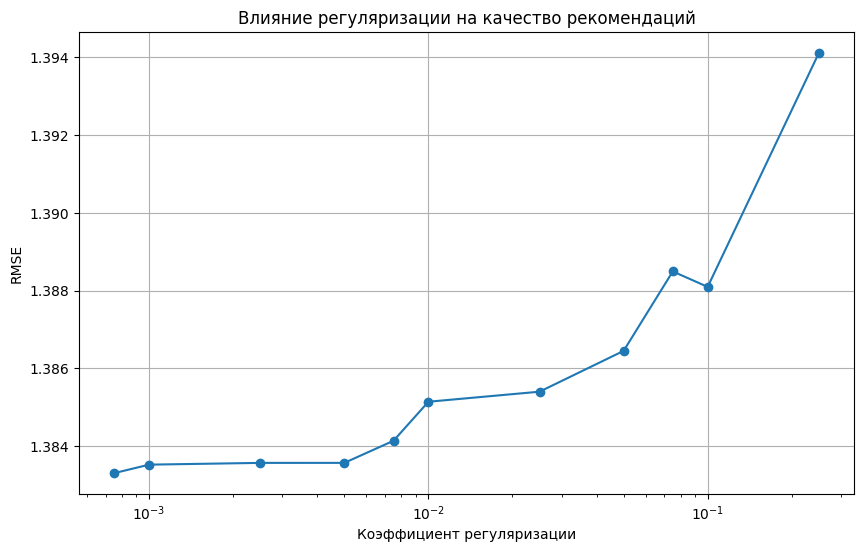

In [20]:
# Исследование влияния регуляризации
regularizations = [0.00075, 0.001, 0.0025, 0.005, 0.0075, 0.01, 0.025, 0.05, 0.075, 0.1, 0.25]
rmse_reg_results = []

print("Исследование влияния регуляризации:")
for reg in tqdm(regularizations):
    rmse, std = evaluate_funksvd_stable(
        interaction_matrix,
        n_factors=70,
        learning_rate=0.01,
        regularization=reg,
        n_epochs=10
    )
    rmse_reg_results.append(rmse)
    print(f"Регуляризация: {reg}, RMSE: {rmse:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(regularizations, rmse_reg_results, marker='o')
plt.title('Влияние регуляризации на качество рекомендаций')
plt.xlabel('Коэффициент регуляризации')
plt.ylabel('RMSE')
plt.xscale('log')
plt.grid(True)
plt.show()

In [53]:
# Этап 8: Финальная модель и рекомендации
def get_recommendations(user_id, model, user_to_idx, game_to_idx, top_n=10):
    if user_id not in user_to_idx:
        return ["Пользователь не найден в системе"]

    user_idx = user_to_idx[user_id]
    n_games = len(game_to_idx)

    # Предсказание рейтингов для всех игр
    predictions = []
    for game_idx in range(n_games):
        pred = model.predict(user_idx, game_idx)
        predictions.append((game_idx, pred))

    # Сортировка по убыванию предсказанного рейтинга
    predictions.sort(key=lambda x: x[1], reverse=True)

    # Получение названий игр
    idx_to_game = {idx: game for game, idx in game_to_idx.items()}
    recommendations = []
    for game_idx, score in predictions[:top_n]:
        game_title = idx_to_game[game_idx]
        recommendations.append((game_title, score))

    return recommendations

# Обучение финальной модели на всех данных
final_model = FunkSVDStable(
    n_factors=70,
    learning_rate=0.01,
    regularization=0.05,
    n_epochs=25
)
final_model.fit(interaction_matrix)

# Пример рекомендаций для случайного пользователя
sample_user = play_data['user-id'].iloc[100]
print(f"Рекомендации для пользователя {sample_user}:")
recommendations = get_recommendations(sample_user, final_model, user_to_idx, game_to_idx, 10)
for i, (game, score) in enumerate(recommendations, 1):
    print(f"{i}. {game} (score: {score:.3f})")

Эпоха 0, RMSE: 0.0639
Эпоха 5, RMSE: 0.0538
Эпоха 10, RMSE: 0.0506
Эпоха 15, RMSE: 0.0491
Эпоха 20, RMSE: 0.0483
Рекомендации для пользователя 53875128:
1. FIFA Manager 09 (score: 0.249)
2. Out of the Park Baseball 16 (score: 0.243)
3. Marvel Puzzle Quest (score: 0.238)
4. Black Ink (score: 0.236)
5. NBA 2K15 (score: 0.221)
6. NBA 2K14 (score: 0.220)
7. Football Manager 2011 (score: 0.216)
8. BlazBlue Continuum Shift Extend (score: 0.216)
9. FINAL FANTASY XIV A Realm Reborn (score: 0.215)
10. Football Manager 2012 (score: 0.215)


In [47]:
# Этап 9: Расширенная финальная модель и рекомендации для нескольких пользователей
def train_final_model(interaction_matrix, best_params):
    model = FunkSVDStable(
        n_factors=best_params['n_factors'],
        learning_rate=best_params['learning_rate'],
        regularization=best_params['regularization'],
        n_epochs=best_params['n_epochs']
    )
    model.fit(interaction_matrix)
    return model

# Используем лучшие параметры из исследования
best_params = {
    'n_factors': 70,
    'learning_rate': 0.01,
    'regularization': 0.05,
    'n_epochs': 10
}

print("Обучение финальной модели...")
final_model = train_final_model(interaction_matrix, best_params)
print("Финальная модель обучена!")

# Улучшенная функция для получения рекомендаций
def get_recommendations_improved(user_id, model, user_to_idx, game_to_idx, top_n=10, already_played=None):
    if user_id not in user_to_idx:
        return ["Пользователь не найден в системе"]

    user_idx = user_to_idx[user_id]
    n_games = len(game_to_idx)

    if already_played is None:
        already_played = set()

    # Предсказание рейтингов для всех игр
    predictions = []
    idx_to_game = {idx: game for game, idx in game_to_idx.items()}

    for game_idx in range(n_games):
        game_title = idx_to_game[game_idx]
        if game_title not in already_played:
            pred = model.predict(user_idx, game_idx)
            predictions.append((game_title, pred))

    # Сортировка по убыванию предсказанного рейтинга
    predictions.sort(key=lambda x: x[1], reverse=True)

    return predictions[:top_n]

# Функция для получения информации об играх пользователя
def get_user_games_info(user_id, play_data):
    user_games = play_data[play_data['user-id'] == user_id][['game-title', 'value', 'log_value']]
    return user_games.sort_values('value', ascending=False)

# Выбираем 5 случайных пользователей
np.random.seed(42)
unique_users = play_data['user-id'].unique()
selected_users = np.random.choice(unique_users, 5, replace=False)

print("=" * 80)
print("АНАЛИЗ РЕКОМЕНДАЦИЙ ДЛЯ 5 СЛУЧАЙНЫХ ПОЛЬЗОВАТЕЛЕЙ")
print("=" * 80)

for i, user_id in enumerate(selected_users, 1):
    print(f"\n{'='*60}")
    print(f"ПОЛЬЗОВАТЕЛЬ {i}: {user_id}")
    print(f"{'='*60}")

    # Получаем игры пользователя
    user_games = get_user_games_info(user_id, play_data)
    user_game_titles = set(user_games['game-title'].unique())

    print(f"\nИгры пользователя (всего {len(user_games)} игр):")
    print("-" * 40)

    # Показываем топ-5 игр по времени
    top_games = user_games.head(5)
    for idx, (_, row) in enumerate(top_games.iterrows(), 1):
        print(f"{idx}. {row['game-title']}: {row['value']:.1f} часов (log: {row['log_value']:.2f})")

    if len(user_games) > 5:
        print(f"... и еще {len(user_games) - 5} игр")

    # Получаем рекомендации
    recommendations = get_recommendations_improved(
        user_id, final_model, user_to_idx, game_to_idx, 10, user_game_titles
    )

    print(f"\nТоп-10 рекомендаций:")
    print("-" * 40)
    for idx, (game, score) in enumerate(recommendations, 1):
        print(f"{idx}. {game} (предсказанный рейтинг: {score:.3f})")

    # Анализ рекомендаций
    print(f"\nСтатистика рекомендаций:")
    print(f"- Средний предсказанный рейтинг: {np.mean([score for _, score in recommendations]):.3f}")
    print(f"- Максимальный предсказанный рейтинг: {max([score for _, score in recommendations]):.3f}")
    print(f"- Минимальный предсказанный рейтинг: {min([score for _, score in recommendations]):.3f}")

Обучение финальной модели...
Эпоха 0, RMSE: 0.0514
Эпоха 5, RMSE: 0.0494
Финальная модель обучена!
АНАЛИЗ РЕКОМЕНДАЦИЙ ДЛЯ 5 СЛУЧАЙНЫХ ПОЛЬЗОВАТЕЛЕЙ

ПОЛЬЗОВАТЕЛЬ 1: 100813586

Игры пользователя (всего 1 игр):
----------------------------------------
1. Total War SHOGUN 2: 2.4 часов (log: 1.22)

Топ-10 рекомендаций:
----------------------------------------
1. Counter-Strike Global Offensive (предсказанный рейтинг: 0.208)
2. NBA 2K14 (предсказанный рейтинг: 0.207)
3. NBA 2K15 (предсказанный рейтинг: 0.204)
4. Sid Meier's Civilization IV Beyond the Sword (предсказанный рейтинг: 0.203)
5. Football Manager 2011 (предсказанный рейтинг: 0.202)
6. Football Manager 2012 (предсказанный рейтинг: 0.201)
7. Arma 3 (предсказанный рейтинг: 0.201)
8. DARK SOULS II (предсказанный рейтинг: 0.201)
9. Might & Magic Heroes VI (предсказанный рейтинг: 0.199)
10. FINAL FANTASY XIV A Realm Reborn (предсказанный рейтинг: 0.199)

Статистика рекомендаций:
- Средний предсказанный рейтинг: 0.202
- Максимальный пре

In [48]:
# Дополнительный анализ: популярность рекомендуемых игр
def analyze_recommendation_popularity(recommended_games, play_data):
    """Анализ популярности рекомендуемых игр"""
    popularity = []
    for game in recommended_games:
        game_players = play_data[play_data['game-title'] == game]['user-id'].nunique()
        popularity.append((game, game_players))

    return sorted(popularity, key=lambda x: x[1], reverse=True)

print("\n" + "="*80)
print("АНАЛИЗ ПОПУЛЯРНОСТИ РЕКОМЕНДУЕМЫХ ИГР")
print("="*80)

# Анализируем популярность рекомендованных игр для всех выбранных пользователей
all_recommended_games = set()
for user_id in selected_users:
    user_games = set(play_data[play_data['user-id'] == user_id]['game-title'].unique())
    recommendations = get_recommendations_improved(
        user_id, final_model, user_to_idx, game_to_idx, 10, user_games
    )
    recommended_titles = [game for game, _ in recommendations]
    all_recommended_games.update(recommended_titles)

# Анализ популярности
popularity_analysis = analyze_recommendation_popularity(all_recommended_games, play_data)

print(f"\nТоп-10 самых популярных рекомендуемых игр (по количеству игроков):")
print("-" * 60)
for idx, (game, players) in enumerate(popularity_analysis[:10], 1):
    total_players = play_data['user-id'].nunique()
    percentage = (players / total_players) * 100
    print(f"{idx}. {game}: {players} игроков ({percentage:.1f}% от всех пользователей)")


АНАЛИЗ ПОПУЛЯРНОСТИ РЕКОМЕНДУЕМЫХ ИГР

Топ-10 самых популярных рекомендуемых игр (по количеству игроков):
------------------------------------------------------------
1. Counter-Strike Global Offensive: 1377 игроков (12.1% от всех пользователей)
2. Arma 3: 157 игроков (1.4% от всех пользователей)
3. Football Manager 2012: 79 игроков (0.7% от всех пользователей)
4. DARK SOULS II: 71 игроков (0.6% от всех пользователей)
5. Might & Magic Heroes VI: 41 игроков (0.4% от всех пользователей)
6. Football Manager 2011: 31 игроков (0.3% от всех пользователей)
7. Sid Meier's Civilization IV Beyond the Sword: 25 игроков (0.2% от всех пользователей)
8. FINAL FANTASY XIV A Realm Reborn: 22 игроков (0.2% от всех пользователей)
9. NBA 2K15: 20 игроков (0.2% от всех пользователей)
10. NBA 2K14: 16 игроков (0.1% от всех пользователей)


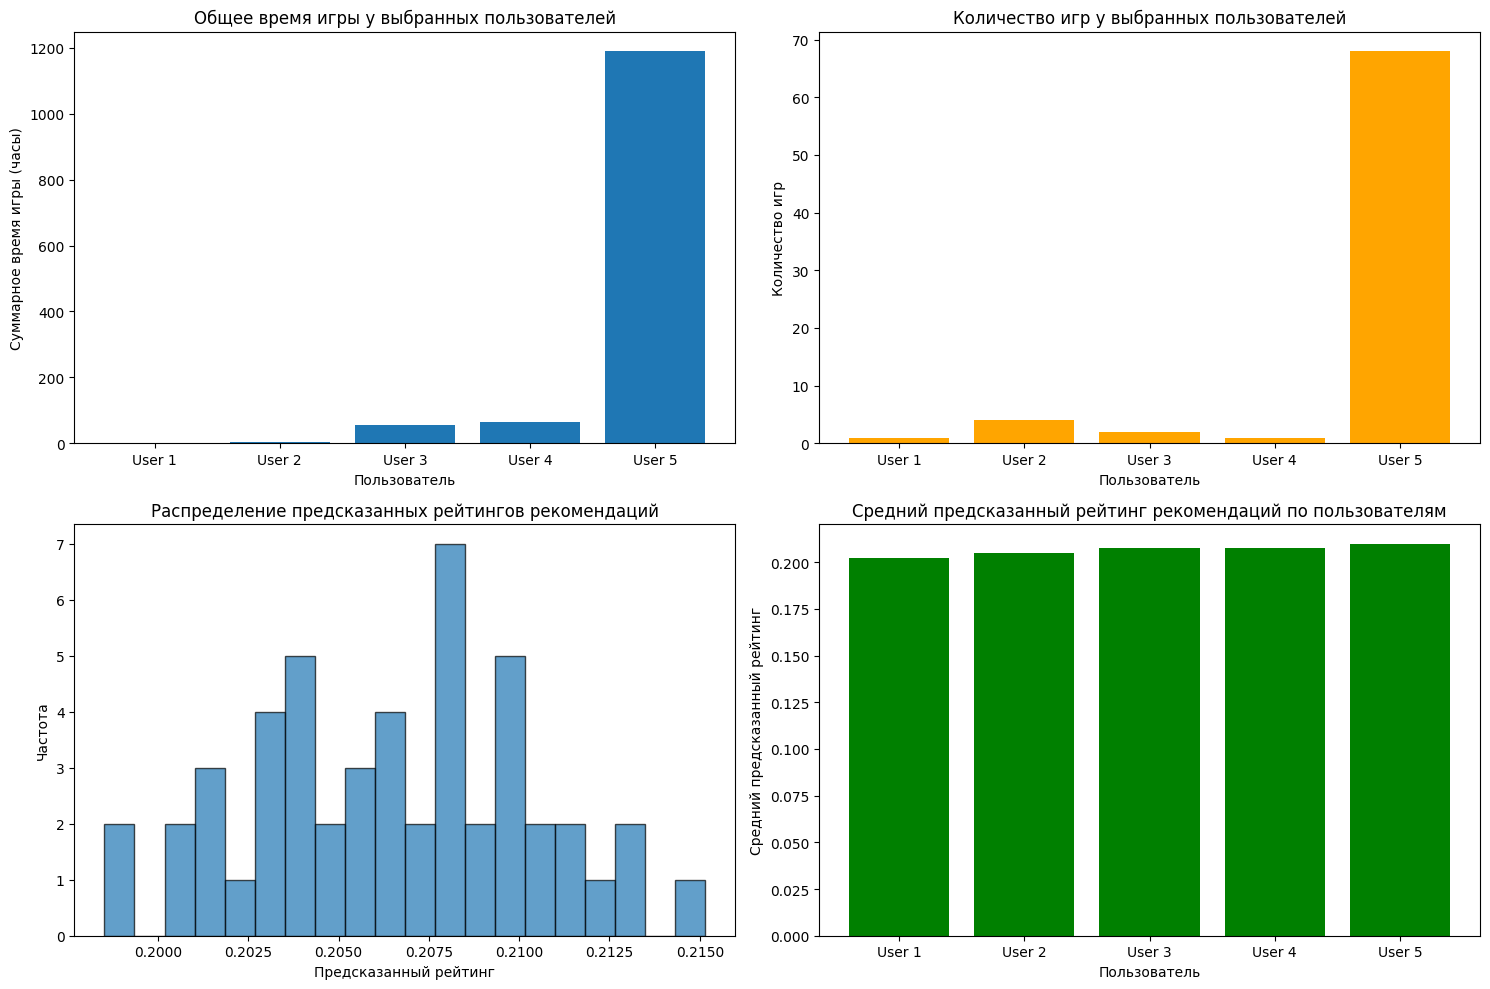

In [49]:
# Визуализация паттернов рекомендаций
plt.figure(figsize=(15, 10))

# 1. Распределение времени игры у выбранных пользователей
plt.subplot(2, 2, 1)
user_playtimes = []
for user_id in selected_users:
    user_playtime = play_data[play_data['user-id'] == user_id]['value'].sum()
    user_playtimes.append(user_playtime)

plt.bar(range(len(selected_users)), user_playtimes)
plt.title('Общее время игры у выбранных пользователей')
plt.xlabel('Пользователь')
plt.ylabel('Суммарное время игры (часы)')
plt.xticks(range(len(selected_users)), [f'User {i+1}' for i in range(len(selected_users))])

# 2. Количество игр у выбранных пользователей
plt.subplot(2, 2, 2)
user_game_counts = []
for user_id in selected_users:
    game_count = play_data[play_data['user-id'] == user_id]['game-title'].nunique()
    user_game_counts.append(game_count)

plt.bar(range(len(selected_users)), user_game_counts, color='orange')
plt.title('Количество игр у выбранных пользователей')
plt.xlabel('Пользователь')
plt.ylabel('Количество игр')
plt.xticks(range(len(selected_users)), [f'User {i+1}' for i in range(len(selected_users))])

# 3. Распределение предсказанных рейтингов рекомендаций
plt.subplot(2, 2, 3)
all_predicted_scores = []
for user_id in selected_users:
    user_games = set(play_data[play_data['user-id'] == user_id]['game-title'].unique())
    recommendations = get_recommendations_improved(
        user_id, final_model, user_to_idx, game_to_idx, 10, user_games
    )
    predicted_scores = [score for _, score in recommendations]
    all_predicted_scores.extend(predicted_scores)

plt.hist(all_predicted_scores, bins=20, edgecolor='black', alpha=0.7)
plt.title('Распределение предсказанных рейтингов рекомендаций')
plt.xlabel('Предсказанный рейтинг')
plt.ylabel('Частота')

# 4. Сравнение средних рейтингов рекомендаций по пользователям
plt.subplot(2, 2, 4)
user_avg_scores = []
for user_id in selected_users:
    user_games = set(play_data[play_data['user-id'] == user_id]['game-title'].unique())
    recommendations = get_recommendations_improved(
        user_id, final_model, user_to_idx, game_to_idx, 10, user_games
    )
    avg_score = np.mean([score for _, score in recommendations])
    user_avg_scores.append(avg_score)

plt.bar(range(len(selected_users)), user_avg_scores, color='green')
plt.title('Средний предсказанный рейтинг рекомендаций по пользователям')
plt.xlabel('Пользователь')
plt.ylabel('Средний предсказанный рейтинг')
plt.xticks(range(len(selected_users)), [f'User {i+1}' for i in range(len(selected_users))])

plt.tight_layout()
plt.show()

In [50]:
# Детальный анализ одного пользователя для демонстрации
def detailed_user_analysis(user_id, model, user_to_idx, game_to_idx, play_data):
    """Детальный анализ пользователя и его рекомендаций"""

    print(f"\n{'='*70}")
    print(f"ДЕТАЛЬНЫЙ АНАЛИЗ ПОЛЬЗОВАТЕЛЯ: {user_id}")
    print(f"{'='*70}")

    # Информация о пользователе
    user_data = play_data[play_data['user-id'] == user_id]
    total_play_time = user_data['value'].sum()
    unique_games = user_data['game-title'].nunique()
    avg_play_time = total_play_time / unique_games if unique_games > 0 else 0

    print(f"\nОбщая статистика:")
    print(f"- Всего игр: {unique_games}")
    print(f"- Общее время игры: {total_play_time:.1f} часов")
    print(f"- Среднее время на игру: {avg_play_time:.1f} часов")

    # Топ игр пользователя
    top_games = user_data.groupby('game-title')['value'].sum().sort_values(ascending=False).head(10)

    print(f"\nТоп-10 игр по времени:")
    for i, (game, time) in enumerate(top_games.items(), 1):
        print(f"{i}. {game}: {time:.1f} часов")

    # Рекомендации
    user_game_titles = set(user_data['game-title'].unique())
    recommendations = get_recommendations_improved(
        user_id, model, user_to_idx, game_to_idx, 15, user_game_titles
    )

    print(f"\nТоп-15 рекомендаций:")
    for i, (game, score) in enumerate(recommendations, 1):
        # Добавляем информацию о популярности игры
        game_popularity = play_data[play_data['game-title'] == game]['user-id'].nunique()
        total_users = play_data['user-id'].nunique()
        popularity_pct = (game_popularity / total_users) * 100

        print(f"{i}. {game}")
        print(f"   Предсказанный рейтинг: {score:.3f}")
        print(f"   Популярность: {game_popularity} игроков ({popularity_pct:.1f}% пользователей)")

    return recommendations

# Детальный анализ первого пользователя из выборки
if len(selected_users) > 0:
    detailed_recommendations = detailed_user_analysis(
        selected_users[1], final_model, user_to_idx, game_to_idx, play_data
    )


ДЕТАЛЬНЫЙ АНАЛИЗ ПОЛЬЗОВАТЕЛЯ: 296656295

Общая статистика:
- Всего игр: 4
- Общее время игры: 4.3 часов
- Среднее время на игру: 1.1 часов

Топ-10 игр по времени:
1. Team Fortress 2: 2.2 часов
2. Aftermath: 1.4 часов
3. Heroes & Generals: 0.6 часов
4. Counter-Strike Nexon Zombies: 0.1 часов

Топ-15 рекомендаций:
1. Counter-Strike Global Offensive
   Предсказанный рейтинг: 0.210
   Популярность: 1377 игроков (12.1% пользователей)
2. NBA 2K15
   Предсказанный рейтинг: 0.208
   Популярность: 20 игроков (0.2% пользователей)
3. NBA 2K14
   Предсказанный рейтинг: 0.208
   Популярность: 16 игроков (0.1% пользователей)
4. Football Manager 2012
   Предсказанный рейтинг: 0.205
   Популярность: 79 игроков (0.7% пользователей)
5. Football Manager 2011
   Предсказанный рейтинг: 0.204
   Популярность: 31 игроков (0.3% пользователей)
6. Sid Meier's Civilization IV Beyond the Sword
   Предсказанный рейтинг: 0.204
   Популярность: 25 игроков (0.2% пользователей)
7. Arma 3
   Предсказанный рейтинг: 0.

In [51]:
# Анализ качества рекомендаций через метрику разнообразия
def calculate_diversity(recommendations_list):
    """Вычисляет разнообразие рекомендаций (сколько уникальных игр рекомендовано)"""
    all_recommended_games = set()
    total_recommendations = 0

    for recommendations in recommendations_list:
        recommended_games = [game for game, _ in recommendations]
        all_recommended_games.update(recommended_games)
        total_recommendations += len(recommended_games)

    diversity = len(all_recommended_games) / total_recommendations if total_recommendations > 0 else 0
    return diversity, len(all_recommended_games), total_recommendations

# Собираем рекомендации для всех выбранных пользователей
all_user_recommendations = []
for user_id in selected_users:
    user_games = set(play_data[play_data['user-id'] == user_id]['game-title'].unique())
    recommendations = get_recommendations_improved(
        user_id, final_model, user_to_idx, game_to_idx, 10, user_games
    )
    all_user_recommendations.append(recommendations)

# Вычисляем метрики разнообразия
diversity_score, unique_games, total_recommendations = calculate_diversity(all_user_recommendations)

print("\n" + "="*60)
print("АНАЛИЗ КАЧЕСТВА РЕКОМЕНДАЦИЙ")
print("="*60)
print(f"Метрики разнообразия рекомендаций для {len(selected_users)} пользователей:")
print(f"- Всего выдано рекомендаций: {total_recommendations}")
print(f"- Уникальных рекомендованных игр: {unique_games}")
print(f"- Коэффициент разнообразия: {diversity_score:.3f}")
print(f"- Среднее разнообразие на пользователя: {unique_games / len(selected_users):.1f} уникальных игр")

# Анализ персонификации рекомендаций
def calculate_personalization(all_user_recommendations):
    """Вычисляет степень персонификации рекомендаций"""
    n_users = len(all_user_recommendations)
    if n_users < 2:
        return 0

    personalization_sum = 0
    pairs = 0

    for i in range(n_users):
        for j in range(i + 1, n_users):
            rec_i = set([game for game, _ in all_user_recommendations[i]])
            rec_j = set([game for game, _ in all_user_recommendations[j]])

            intersection = len(rec_i.intersection(rec_j))
            union = len(rec_i.union(rec_j))

            jaccard_similarity = intersection / union if union > 0 else 0
            personalization_sum += (1 - jaccard_similarity)
            pairs += 1

    return personalization_sum / pairs if pairs > 0 else 0

personalization_score = calculate_personalization(all_user_recommendations)
print(f"- Степень персонификации: {personalization_score:.3f}")
print("  (1.0 = полностью уникальные рекомендации для каждого пользователя)")
print("  (0.0 = одинаковые рекомендации для всех пользователей)")


АНАЛИЗ КАЧЕСТВА РЕКОМЕНДАЦИЙ
Метрики разнообразия рекомендаций для 5 пользователей:
- Всего выдано рекомендаций: 50
- Уникальных рекомендованных игр: 10
- Коэффициент разнообразия: 0.200
- Среднее разнообразие на пользователя: 2.0 уникальных игр
- Степень персонификации: 0.000
  (1.0 = полностью уникальные рекомендации для каждого пользователя)
  (0.0 = одинаковые рекомендации для всех пользователей)
